In [1]:
import os
os.chdir(os.path.expanduser("~/ransomware_xai_project"))

# Verify the files exist before loading
print("Files in data/:", [f for f in os.listdir("data/") if f.endswith('.csv')])
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
import joblib, os, time, warnings
warnings.filterwarnings('ignore')
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix, roc_curve)
os.makedirs("models", exist_ok=True)
os.makedirs("results/figures", exist_ok=True)
os.makedirs("results/tables", exist_ok=True)
X_train = pd.read_csv("data/X_train_selected.csv", index_col=0)
X_test = pd.read_csv("data/X_test_selected.csv", index_col=0)
y_train = pd.read_csv("data/y_train.csv", index_col=0).squeeze()
y_test = pd.read_csv("data/y_test.csv", index_col=0).squeeze()
fn = X_train.columns.tolist()
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print(f"Train: {X_train.shape} | Test: {X_test.shape} | Features: {len(fn)}")

Files in data/: ['MalMem2022.csv', 'X_test_selected.csv', 'X_test_unscaled.csv', 'X_train_unscaled.csv', 'y_train.csv', 'X_train_selected.csv', 'y_test.csv']
Train: (46876, 20) | Test: (11720, 20) | Features: 20


In [3]:
print("Training Decision Tree...")
dt = GridSearchCV(DecisionTreeClassifier(random_state=42),
    {'max_depth':[3,5,10,None],'min_samples_split':[2,5],'criterion':['gini','entropy']},
    cv=cv, scoring='f1', n_jobs=-1)
dt.fit(X_train, y_train)
dt_model = dt.best_estimator_
joblib.dump(dt_model, "models/dt_model.joblib")
print(f"Done | CV F1: {dt.best_score_:.4f} | {dt.best_params_}")

Training Decision Tree...
Done | CV F1: 0.9998 | {'criterion': 'entropy', 'max_depth': 10, 'min_samples_split': 2}


In [4]:
print("Training EBM...")
from interpret.glassbox import ExplainableBoostingClassifier
ebm_model = ExplainableBoostingClassifier(max_bins=256, interactions=10, learning_rate=0.05, random_state=42)
ebm_model.fit(X_train, y_train)
joblib.dump(ebm_model, "models/ebm_model.joblib")
print(f"Done | Test F1: {f1_score(y_test, ebm_model.predict(X_test)):.4f}")

Training EBM...
Done | Test F1: 1.0000


In [5]:
print("Training Random Forest...")
rf = GridSearchCV(RandomForestClassifier(random_state=42, n_jobs=-1),
    {'n_estimators':[100,200],'max_depth':[10,20,None],'min_samples_split':[2,5]},
    cv=cv, scoring='f1', n_jobs=-1)
rf.fit(X_train, y_train)
rf_model = rf.best_estimator_
joblib.dump(rf_model, "models/rf_model.joblib")
print(f"Done | CV F1: {rf.best_score_:.4f} | {rf.best_params_}")

Training Random Forest...
Done | CV F1: 0.9999 | {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}


In [6]:
print("Training XGBoost...")
try:
    from xgboost import XGBClassifier
    xgb = GridSearchCV(XGBClassifier(random_state=42, eval_metric='logloss', n_jobs=-1),
        {'n_estimators':[100,200],'max_depth':[3,6],'learning_rate':[0.01,0.1,0.3]},
        cv=cv, scoring='f1', n_jobs=-1)
    xgb.fit(X_train, y_train)
    xgb_model = xgb.best_estimator_
    print(f"Done | CV F1: {xgb.best_score_:.4f} | {xgb.best_params_}")
except Exception as e:
    print(f"XGBoost error: {e}")
    xgb_model = GradientBoostingClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42)
    xgb_model.fit(X_train, y_train)
    print(f"Done | Used GradientBoosting instead")
joblib.dump(xgb_model, "models/xgb_model.joblib")

Training XGBoost...
Done | CV F1: 0.9999 | {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}


['models/xgb_model.joblib']

In [7]:
print("Training Logistic Regression...")
lr_model = LogisticRegression(C=1, penalty='l2', solver='liblinear', random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)
joblib.dump(lr_model, "models/lr_model.joblib")
print(f"Done | Test F1: {f1_score(y_test, lr_model.predict(X_test)):.4f}")

Training Logistic Regression...
Done | Test F1: 0.9985


In [8]:
models = {'Decision Tree':dt_model, 'EBM':ebm_model, 'Random Forest':rf_model, 'XGBoost':xgb_model, 'Logistic Regression':lr_model}
results = []
for name, model in models.items():
    y_pred = model.predict(X_test)
    try:
        y_proba = model.predict_proba(X_test)[:,1]
    except:
        y_proba = model.predict_proba(pd.DataFrame(X_test.values, columns=fn))[:,1]
    tn,fp,fneg,tp = confusion_matrix(y_test, y_pred).ravel()
    results.append({'Model':name,'Accuracy':round(accuracy_score(y_test,y_pred),4),'Precision':round(precision_score(y_test,y_pred),4),'Recall':round(recall_score(y_test,y_pred),4),'F1-Score':round(f1_score(y_test,y_pred),4),'ROC-AUC':round(roc_auc_score(y_test,y_proba),4),'FPR':round(fp/(fp+tn),4),'TP':tp,'FP':fp,'FN':fneg,'TN':tn})
results_df = pd.DataFrame(results)
results_df.to_csv("results/tables/model_comparison.csv", index=False)
print(results_df[['Model','Accuracy','Precision','Recall','F1-Score','ROC-AUC','FPR']].to_string(index=False))
print(f"\nBEST: {results_df.loc[results_df['F1-Score'].idxmax(),'Model']}")

              Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC    FPR
      Decision Tree    0.9997     0.9998  0.9997    0.9997   0.9997 0.0002
                EBM    1.0000     1.0000  1.0000    1.0000   1.0000 0.0000
      Random Forest    1.0000     1.0000  1.0000    1.0000   1.0000 0.0000
            XGBoost    0.9999     0.9998  1.0000    0.9999   1.0000 0.0002
Logistic Regression    0.9985     0.9985  0.9985    0.9985   1.0000 0.0015

BEST: EBM


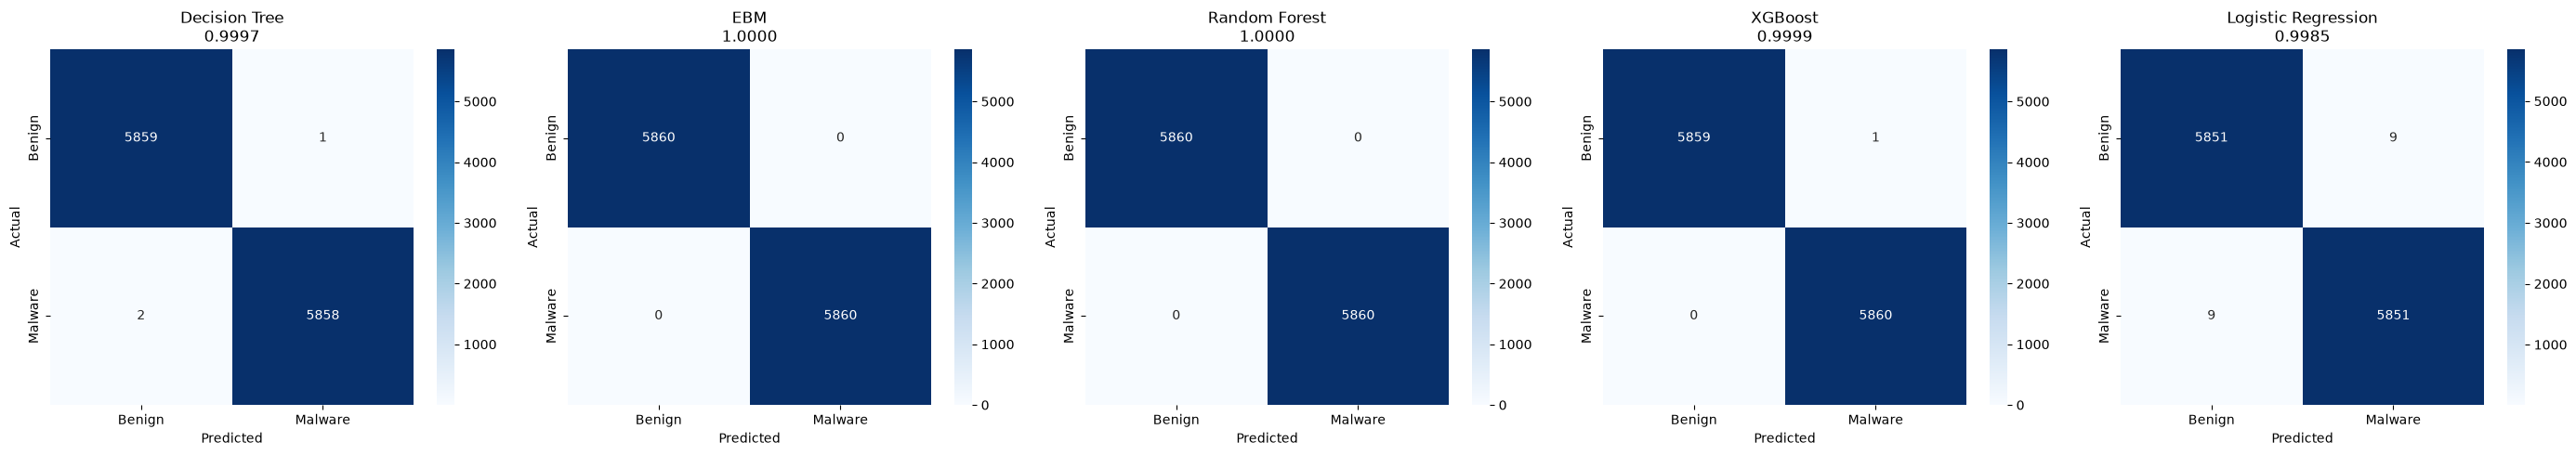

In [9]:
fig, axes = plt.subplots(1,5,figsize=(28,5))
for ax,(name,model) in zip(axes, models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, xticklabels=['Benign','Malware'], yticklabels=['Benign','Malware'])
    ax.set_title(f"{name}\n{accuracy_score(y_test,y_pred):.4f}")
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig("results/figures/confusion_matrices_all.png", dpi=300, bbox_inches='tight')
plt.show()

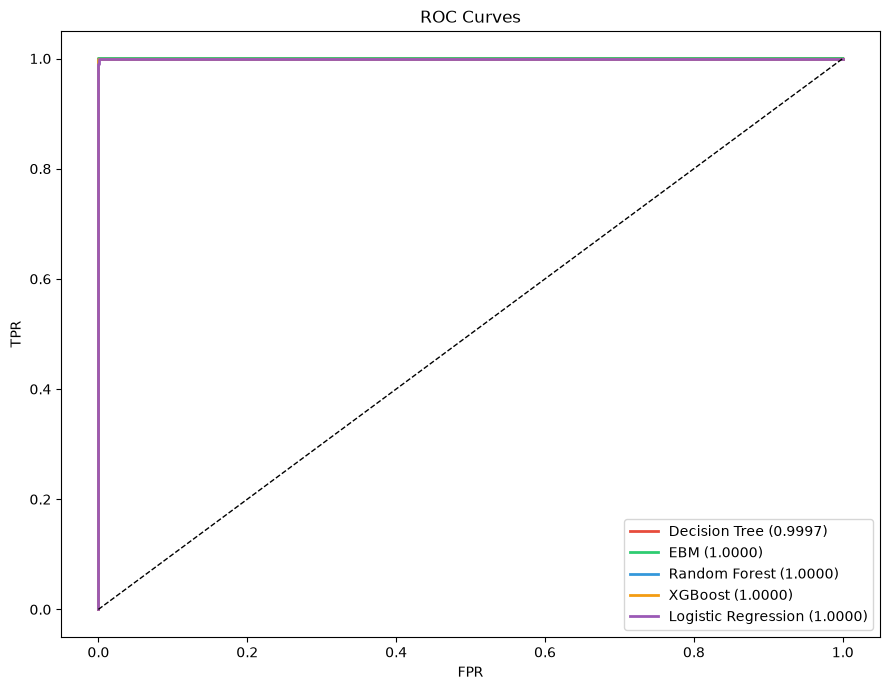

In [10]:
fig, ax = plt.subplots(figsize=(9,7))
colors = ['#e74c3c','#2ecc71','#3498db','#f39c12','#9b59b6']
for (name,model),color in zip(models.items(), colors):
    try:
        y_proba = model.predict_proba(X_test)[:,1]
    except:
        y_proba = model.predict_proba(pd.DataFrame(X_test.values, columns=fn))[:,1]
    fpr_v, tpr_v, _ = roc_curve(y_test, y_proba)
    ax.plot(fpr_v, tpr_v, color=color, lw=2, label=f"{name} ({roc_auc_score(y_test,y_proba):.4f})")
ax.plot([0,1],[0,1],'k--',lw=1)
ax.set_title('ROC Curves'); ax.legend(loc='lower right')
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
plt.tight_layout()
plt.savefig("results/figures/roc_curves_all.png", dpi=300, bbox_inches='tight')
plt.show()

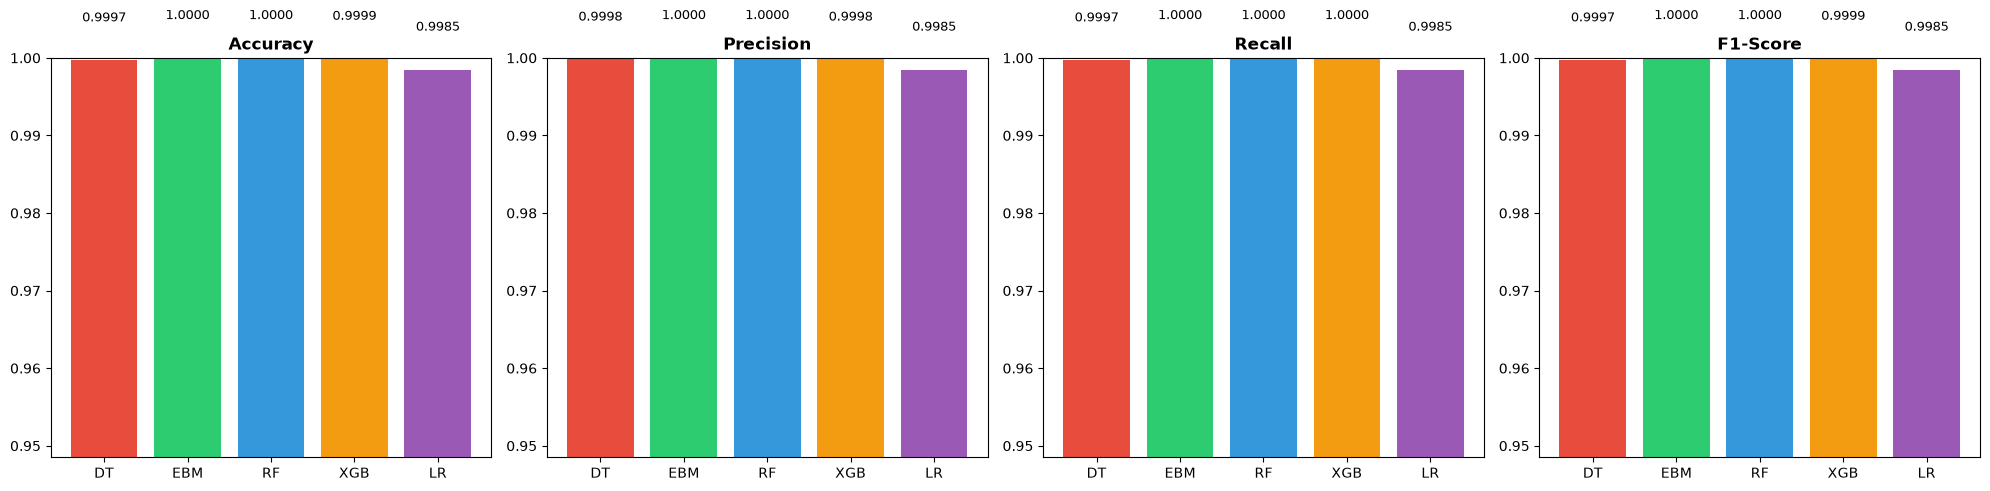

In [11]:
fig, axes = plt.subplots(1,4,figsize=(20,5))
for ax, metric in zip(axes, ['Accuracy','Precision','Recall','F1-Score']):
    vals = results_df[metric].values
    bars = ax.bar(range(5), vals, color=['#e74c3c','#2ecc71','#3498db','#f39c12','#9b59b6'])
    ax.set_xticks(range(5)); ax.set_xticklabels(['DT','EBM','RF','XGB','LR'])
    ax.set_title(metric, fontweight='bold'); ax.set_ylim(min(vals)-0.05, 1.0)
    for bar,val in zip(bars,vals):
        ax.text(bar.get_x()+bar.get_width()/2., bar.get_height()+0.005, f'{val:.4f}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig("results/figures/performance_bars.png", dpi=300, bbox_inches='tight')
plt.show()

In [12]:
print("COMPLETE — All files saved:")
for f in sorted(os.listdir("models")):
    print(f"  models/{f}")
for folder in ['results/tables','results/figures']:
    for f in sorted(os.listdir(folder)):
        print(f"  {folder}/{f}")

COMPLETE — All files saved:
  models/.ipynb_checkpoints
  models/dt_model.joblib
  models/ebm_model.joblib
  models/lr_model.joblib
  models/rf_model.joblib
  models/xgb_model.joblib
  results/tables/.ipynb_checkpoints
  results/tables/cross_validation_results.csv
  results/tables/dual_criterion_comparison.csv
  results/tables/feature_importance_RF.csv
  results/tables/final_model_comparison.csv
  results/tables/lime_rankings_all_models.csv
  results/tables/model_comparison.csv
  results/tables/shap_lime_consistency.csv
  results/tables/shap_rankings_all_models.csv
  results/figures/.ipynb_checkpoints
  results/figures/confusion_matrices_all.png
  results/figures/feature_importance_RF.png
  results/figures/lime_explanation_RF.png
  results/figures/lime_explanation_example.html
  results/figures/mutual_information_scores.png
  results/figures/performance_bars.png
  results/figures/performance_heatmap.png
  results/figures/precision_recall_curves.png
  results/figures/roc_curves_all.png
